In [1]:
%matplotlib inline

# Marginal Fitting: Nationalities

* *nation* is fixed to match the BFS predictions per age canton and age
* The choice of persons to fix is done randomly

In [2]:
import logging
import os
import sys

from matplotlib import pyplot as plt
import pandas as pd

In [3]:
sys.path.append(r'X:\90_Persoenlich\u229285\dev\SynPopToolbox')

In [4]:
from synpop.visualisations import save_figure, plot_binary_feature_per_age_with_marginals
from synpop import marginal_fitting, utils
from synpop.synpop import Persons
from synpop.marginals import FSO_PopPredictionsClient

In [5]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)  # Set logging level: WARNING, INFO, DEBUG

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Settings" data-toc-modified-id="Settings-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Settings</a></span></li><li><span><a href="#Loading-Data" data-toc-modified-id="Loading-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Loading Data</a></span><ul class="toc-item"><li><span><a href="#SynPop" data-toc-modified-id="SynPop-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>SynPop</a></span><ul class="toc-item"><li><span><a href="#Scenario-Year" data-toc-modified-id="Scenario-Year-2.1.1"><span class="toc-item-num">2.1.1&nbsp;&nbsp;</span>Scenario-Year</a></span></li></ul></li><li><span><a href="#FSO-Data" data-toc-modified-id="FSO-Data-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>FSO Data</a></span></li></ul></li><li><span><a href="#Examining-SynPop-raw" data-toc-modified-id="Examining-SynPop-raw-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Examining SynPop-raw</a></span><ul class="toc-item"><li><span><a href="#Global-Counts" data-toc-modified-id="Global-Counts-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Global Counts</a></span></li><li><span><a href="#Marginals-Per-Age" data-toc-modified-id="Marginals-Per-Age-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Marginals Per Age</a></span><ul class="toc-item"><li><span><a href="#Global" data-toc-modified-id="Global-3.2.1"><span class="toc-item-num">3.2.1&nbsp;&nbsp;</span>Global</a></span></li><li><span><a href="#A-few-examples" data-toc-modified-id="A-few-examples-3.2.2"><span class="toc-item-num">3.2.2&nbsp;&nbsp;</span>A few examples</a></span></li></ul></li></ul></li><li><span><a href="#Fixing-methodology" data-toc-modified-id="Fixing-methodology-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Fixing methodology</a></span><ul class="toc-item"><li><span><a href="#Expected-Counts" data-toc-modified-id="Expected-Counts-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Expected Counts</a></span></li><li><span><a href="#Fixing..." data-toc-modified-id="Fixing...-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Fixing...</a></span></li></ul></li><li><span><a href="#Examining-SynPop+" data-toc-modified-id="Examining-SynPop+-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Examining SynPop+</a></span><ul class="toc-item"><li><span><a href="#Global-Counts" data-toc-modified-id="Global-Counts-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Global Counts</a></span></li><li><span><a href="#Marginals-Per-Age" data-toc-modified-id="Marginals-Per-Age-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Marginals Per Age</a></span><ul class="toc-item"><li><span><a href="#Global" data-toc-modified-id="Global-5.2.1"><span class="toc-item-num">5.2.1&nbsp;&nbsp;</span>Global</a></span></li><li><span><a href="#A-few-examples" data-toc-modified-id="A-few-examples-5.2.2"><span class="toc-item-num">5.2.2&nbsp;&nbsp;</span>A few examples</a></span></li></ul></li></ul></li><li><span><a href="#Saving-Results" data-toc-modified-id="Saving-Results-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Saving Results</a></span></li><li><span><a href="#Export-Notebook-to-HTML" data-toc-modified-id="Export-Notebook-to-HTML-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Export Notebook to HTML</a></span></li></ul></div>

##  Settings

In [6]:
YEAR = 2040

DATA_DIR = r'\\k13536\mobi\10_Daten\SynPop\2040\02_preprocessed'
SYNPOP_PERSONS_FILE = os.path.join(DATA_DIR, 'persons_{}.pickle.gzip'.format(YEAR))

**Export Settings**

In [7]:
SAVE_OUTPUTS = True
OUTPUT_DIR = './outputs'
FIG_FORMAT = 'png'
FIG_DPI = 150
FIG_BBOX_INCHES = 'tight'
FIG_PAD_INCHES = 0.1

In [8]:
utils.create_dir(OUTPUT_DIR)

2020-04-20 15:54:43,376 - INFO - synpop.utils: "./outputs" exists already


## Loading Data

### SynPop

In [9]:
COLUMNS_OF_INTEREST = ['person_id', 'language', 'nation', 'age', 'location_id', 'KT', 'N_KT', 'ID_Gem', 'N_Gem', 'KT_full' ]

#### Scenario-Year

In [10]:
SYNPOP_PERSONS_FILE

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2040\\02_preprocessed\\persons_2040.pickle.gzip'

In [11]:
%%time
synpop_persons = Persons(YEAR)
synpop_persons.load_pickle(SYNPOP_PERSONS_FILE)

persons = synpop_persons.data[COLUMNS_OF_INTEREST].copy(deep=True)
persons['is_swiss'] = persons['nation'] == 'swiss'

del synpop_persons

2020-04-20 15:54:43,419 - INFO - synpop.synpop: Loading \\k13536\mobi\10_Daten\SynPop\2040\02_preprocessed\persons_2040.pickle.gzip ...
2020-04-20 15:55:00,224 - INFO - synpop.synpop: Table persons loaded with 10037464 rows.


Wall time: 22.5 s


In [12]:
print('Imported data:')
print('persons DataFrame for {}: {}'.format(YEAR, persons.shape))

Imported data:
persons DataFrame for 2040: (10037464, 11)


### FSO Data

In [13]:
%%time
bfs_pred = FSO_PopPredictionsClient().load(year=YEAR).pop_by_canton_age_and_nationality

Wall time: 7.3 s


In [14]:
bfs_counts = bfs_pred.set_index(['KT_full', 'age', 'is_swiss'])['pop']
bfs_totals_per_cat = bfs_pred.groupby(['KT_full', 'age']).sum()['pop']
bfs_predicted_ratio = (bfs_counts / bfs_totals_per_cat).dropna()

2020-04-20 15:55:13,324 - INFO - numexpr.utils: NumExpr defaulting to 8 threads.


## Examining SynPop-raw

In [15]:
COLOUR_DICT = {'true': 'firebrick', 'false': 'grey'}

### Global Counts

In [16]:
synpop_counts = (persons.groupby('is_swiss').count().iloc[:, 0]).loc[True]
synpop_rel = (synpop_counts / persons.shape[0]) 

bfs_counts = (bfs_pred.groupby('is_swiss')['pop'].sum()).loc[True]
bfs_rel = bfs_counts / bfs_pred['pop'].sum()

global_stats = pd.DataFrame({'pop':     {'synpop-raw': persons.shape[0], 
                                         'bfs': bfs_pred['pop'].sum()},
                             'swiss':   {'synpop-raw': synpop_counts, 
                                         'bfs': bfs_counts},
                             '% swiss': {'synpop-raw': int(synpop_rel * 100), 
                                          'bfs': int(bfs_rel * 100)}
                            }
                           )
print(YEAR)
global_stats

2040


,pop,swiss,% swiss
synpop-raw,10037464,5367929,53
bfs,10013978,6960185,69


### Marginals Per Age

In [17]:
%%time
marginals = marginal_fitting.compute_bfs_vs_scenario_marginal_summary_table(persons, 
                                                                              bfs_predicted_ratio, 
                                                                              YEAR, 
                                                                              feature='is_swiss', 
                                                                              control_level_list=['KT_full', 'age']
                                                                             )

Wall time: 9.4 s


In [18]:
counts_per_cat = (marginals
                  .reset_index()
                  .astype({'is_swiss': str})  # to avoid boolean values as column names
                  .pivot_table(index=['KT_full', 'age'], columns='is_swiss', values='counts_{}'.format(YEAR))
                  .fillna(0)
                  .astype(int)
                  .rename(columns={'True': 'true', 'False': 'false'})  # to avoid confusion between bool and str
                 )
counts_per_cat = counts_per_cat[['true', 'false']]

In [19]:
expected_true_counts = (marginals['expected_counts_{}'.format(YEAR)]
                        .reset_index()
                        .query('is_swiss')
                        .groupby(['KT_full', 'age']).sum()['expected_counts_{}'.format(YEAR)]
                        .rename('bfs: {} prediction'.format('is_swiss'))
                       )

#### Global

In [20]:
marginals.head()

expected_ratios_2040  counts_2040  expected_counts_2040  \
KT_full age is_swiss                                                            
Aargau  0   False                 0.000000         3763                     0   
            True                  0.000000         3547                     0   
        1   False                 0.315534         3877                  2331   
            True                  0.684466         3513                  5058   
        2   False                 0.313903         3970                  2387   

                      deltas_2040  
KT_full age is_swiss               
Aargau  0   False            3763  
            True             3547  
        1   False            1546  
            True            -1545  
        2   False            1583

2020-04-20 15:55:28,643 - INFO - root: Figure saved to file : ./outputs\02_01_SynPop2040_raw_nationality_global.png


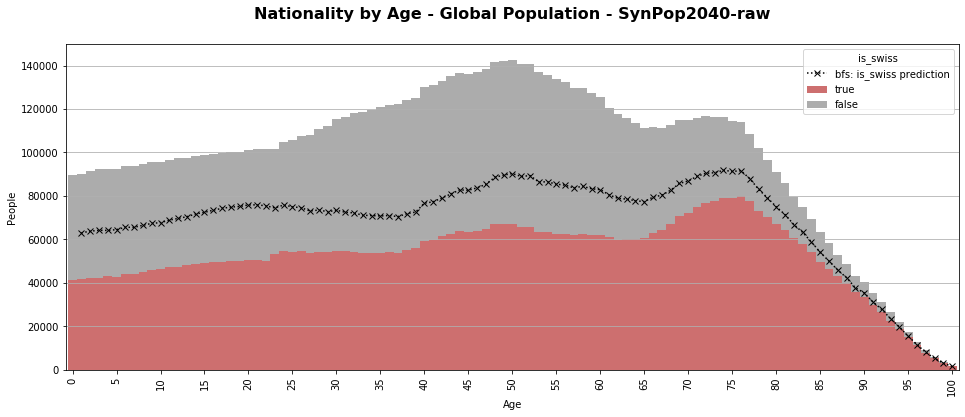

In [21]:
title = 'Nationality by Age - Global Population - SynPop{}-raw'.format(YEAR)

ax = plot_binary_feature_per_age_with_marginals(counts_per_cat.groupby(level=1).sum(), 
                                                expected_true_counts.groupby(level=1).sum(),
                                                colour_dict=COLOUR_DICT, ymax=150_000, title=title)

save_figure(SAVE_OUTPUTS, '02_01_SynPop{}_raw_nationality_global.{}'.format(YEAR, FIG_FORMAT),
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

#### A few examples

*Ticino*

In [22]:
CANTON = 'Ticino'

In [23]:
marginals.loc[CANTON]

expected_ratios_2040  counts_2040  expected_counts_2040  \
age is_swiss                                                            
0   False                 0.000000         1887                     0   
    True                  0.000000         1826                     0   
1   False                 0.277286         1880                   986   
    True                  0.722714         1677                  2570   
2   False                 0.283211         1779                   974   
...                            ...          ...                   ...   
129 True                  0.000000            1                     0   
131 False                 0.000000            0                     0   
    True                  0.000000            0                     0   
132 False                 0.000000            0                     0   
    True                  0.000000            0                     0   

              deltas_2040  
age is_swiss               
0   False            1887  
    True             1826  
1   False             894  
    True             -893  
2   False             805  
...                   ...  
129 True                1  
131 False               0  
    True                0  
132 False               0  
    True                0  

[264 rows x 4 columns]

2020-04-20 15:55:30,476 - INFO - root: Figure saved to file : ./outputs\02_02_SynPop2040_raw_nationality_ticino.png


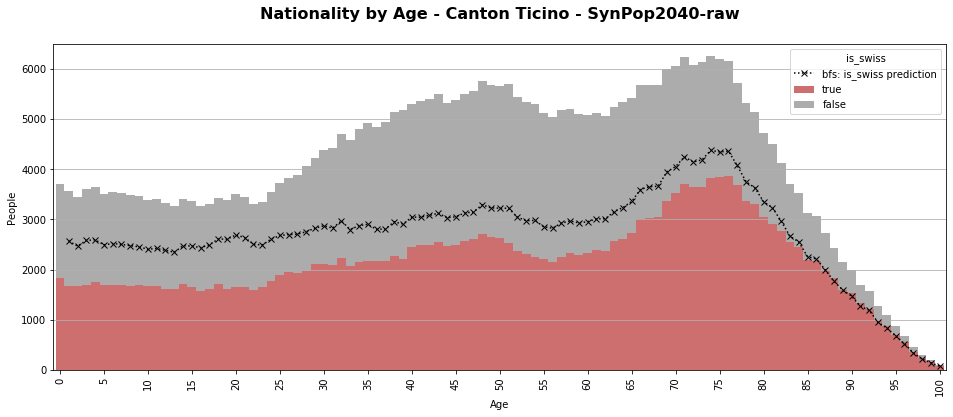

In [24]:
title = 'Nationality by Age - Canton {} - SynPop{}-raw'.format(CANTON, YEAR)

ax = plot_binary_feature_per_age_with_marginals(counts_per_cat.loc[CANTON], 
                                                expected_true_counts.loc[CANTON],
                                                colour_dict=COLOUR_DICT, ymax=6_500, title=title)

save_figure(SAVE_OUTPUTS, '02_02_SynPop{}_raw_nationality_ticino.{}'.format(YEAR, FIG_FORMAT),
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

*Zürich*

In [25]:
CANTON = 'Zürich'

In [26]:
marginals.loc[CANTON]

expected_ratios_2040  counts_2040  expected_counts_2040  \
age is_swiss                                                            
0   False                 0.000000         8668                     0   
    True                  0.000000         6463                     0   
1   False                 0.315614         8976                  4895   
    True                  0.684386         6536                 10616   
2   False                 0.317909         9228                  5068   
...                            ...          ...                   ...   
129 True                  0.000000            0                     0   
131 False                 0.000000            0                     0   
    True                  0.000000            0                     0   
132 False                 0.000000            0                     0   
    True                  0.000000            2                     0   

              deltas_2040  
age is_swiss               
0   False            8668  
    True             6463  
1   False            4081  
    True            -4080  
2   False            4160  
...                   ...  
129 True                0  
131 False               0  
    True                0  
132 False               0  
    True                2  

[264 rows x 4 columns]

2020-04-20 15:55:32,177 - INFO - root: Figure saved to file : ./outputs\02_03_SynPop2040_raw_nationality_zurich.png


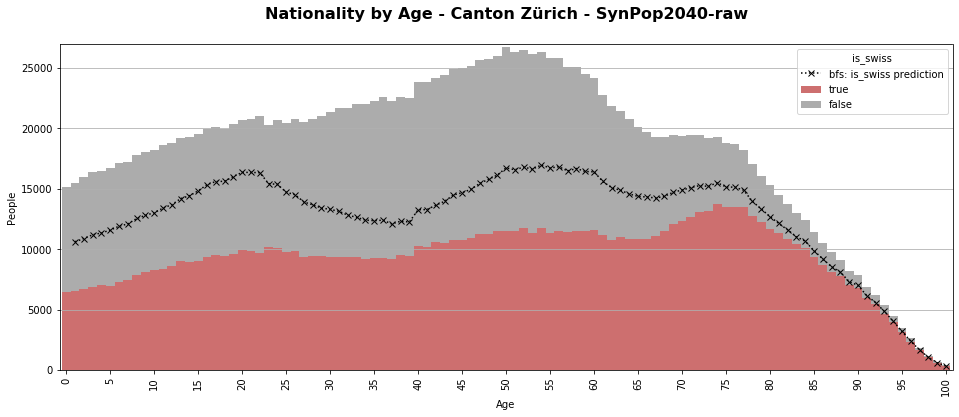

In [27]:
title = 'Nationality by Age - Canton {} - SynPop{}-raw'.format(CANTON, YEAR)

ax = plot_binary_feature_per_age_with_marginals(counts_per_cat.loc[CANTON], 
                                                expected_true_counts.loc[CANTON],
                                                colour_dict=COLOUR_DICT, ymax=27_000, title=title)

save_figure(SAVE_OUTPUTS, '02_03_SynPop{}_raw_nationality_zurich.{}'.format(YEAR, FIG_FORMAT),
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

## Fixing methodology

### Expected Counts

In [28]:
expected_pop_counts = (marginals['expected_counts_{}'.format(YEAR)].rename('expected_counts')
                       .reset_index()
                       .pivot_table(index=['KT_full', 'age'], columns='is_swiss', values='expected_counts')
                       .fillna(0).astype(int) 
                      )

In [29]:
expected_pop_counts

is_swiss     False  True 
KT_full age              
Aargau  0        0      0
        1     2331   5058
        2     2387   5218
        3     2345   5179
        4     2286   5074
...            ...    ...
Zürich  127      0      0
        128      0      0
        129      0      0
        131      0      0
        132      0      0

[3432 rows x 2 columns]

### Fixing...

The logging can be set to `INFO` or `DEBUG` (at the top of the notebook `logger.setLevel(logging.INFO)`) based on how much detail is needed!

**This is going to take a few minutes to run!**

In [30]:
fixed_swiss = marginal_fitting.fix_categorical_feature(persons=persons,
                                                       feature='is_swiss',
                                                       pop_segment_variables=['KT_full', 'age'],
                                                       control_totals=expected_pop_counts,
                                                       person_proba=None  # totally random
                                                       )

fixed_swiss = fixed_swiss == 'true'  # Turning it back into a boolean

2020-04-20 15:55:33,586 - INFO - synpop.marginal_fitting: Since no probability model has been given, a uniform distribution will be used.
2020-04-20 15:55:46,345 - INFO - synpop.marginal_fitting: Fixing "is_swiss" by population segments based on: ['KT_full', 'age']
2020-04-20 15:56:03,650 - INFO - synpop.marginal_fitting: 20 / 3268 population segments fixed...
2020-04-20 15:56:03,991 - INFO - synpop.marginal_fitting: 40 / 3268 population segments fixed...
2020-04-20 15:56:04,349 - INFO - synpop.marginal_fitting: 60 / 3268 population segments fixed...
2020-04-20 15:56:04,658 - INFO - synpop.marginal_fitting: 80 / 3268 population segments fixed...
2020-04-20 15:56:04,921 - INFO - synpop.marginal_fitting: 100 / 3268 population segments fixed...
2020-04-20 15:56:05,107 - INFO - synpop.marginal_fitting: 120 / 3268 population segments fixed...
2020-04-20 15:56:05,311 - INFO - synpop.marginal_fitting: 140 / 3268 population segments fixed...
2020-04-20 15:56:05,579 - INFO - synpop.marginal_fit

In [31]:
persons_fixed = persons.copy(deep=True)
persons_fixed = persons_fixed.drop('is_swiss', axis=1)
persons_fixed = pd.merge(persons_fixed, fixed_swiss, left_on='person_id', right_index=True)

##  Examining SynPop+

### Global Counts

In [32]:
synpop_counts_fixed = (persons_fixed.groupby('is_swiss').count().iloc[:, 0]).loc[True]
synpop_rel_fixed = (synpop_counts_fixed / persons_fixed.shape[0]) 

global_stats = pd.DataFrame({'pop':     {'synpop-raw': persons.shape[0],
                                         'synpop+': persons_fixed.shape[0],
                                         'bfs': bfs_pred['pop'].sum()},
                             'swiss':   {'synpop-raw': synpop_counts, 
                                         'synpop+': synpop_counts_fixed, 
                                         'bfs': bfs_counts},
                             '% swiss': {'synpop-raw': int(synpop_rel * 100), 
                                         'synpop+': int(synpop_rel_fixed * 100), 
                                          'bfs': int(bfs_rel * 100)}
                            }
                           )
print(YEAR)
global_stats

2040


,pop,swiss,% swiss
synpop-raw,10037464,5367929,53
synpop+,10037464,6950059,69
bfs,10013978,6960185,69


### Marginals Per Age

In [33]:
%%time
marginals_fixed = marginal_fitting.compute_bfs_vs_scenario_marginal_summary_table(persons_fixed, 
                                                                                  bfs_predicted_ratio, 
                                                                                  YEAR, 
                                                                                  feature='is_swiss', 
                                                                                  control_level_list=['KT_full', 'age']
                                                                                 )

Wall time: 9.41 s


In [34]:
counts_per_cat_fixed = (marginals_fixed
                        .reset_index()
                        .astype({'is_swiss': str})  # to avoid boolean values as column names
                        .pivot_table(index=['KT_full', 'age'], columns='is_swiss', values='counts_{}'.format(YEAR))
                        .fillna(0)
                        .astype(int)
                        .rename(columns={'True': 'true', 'False': 'false'})  # to avoid confusion between bool and str
                        )
counts_per_cat_fixed = counts_per_cat_fixed[['true', 'false']]

In [35]:
expected_true_counts_fixed = (marginals_fixed['expected_counts_{}'.format(YEAR)]
                        .reset_index()
                        .query('is_swiss')
                        .groupby(['KT_full', 'age']).sum()['expected_counts_{}'.format(YEAR)]
                        .rename('bfs: {} prediction'.format('is_swiss'))
                       )

#### Global

In [36]:
marginals_fixed

expected_ratios_2040  counts_2040  expected_counts_2040  \
KT_full age is_swiss                                                            
Aargau  0   False                 0.000000         3763                     0   
            True                  0.000000         3547                     0   
        1   False                 0.315534         2332                  2331   
            True                  0.684466         5058                  5058   
        2   False                 0.313903         2388                  2387   
...                                    ...          ...                   ...   
Zürich  129 True                  0.000000            0                     0   
        131 False                 0.000000            0                     0   
            True                  0.000000            0                     0   
        132 False                 0.000000            0                     0   
            True                  0.000000            2                     0   

                      deltas_2040  
KT_full age is_swiss               
Aargau  0   False            3763  
            True             3547  
        1   False               1  
            True                0  
        2   False               1  
...                           ...  
Zürich  129 True                0  
        131 False               0  
            True                0  
        132 False               0  
            True                2  

[6864 rows x 4 columns]

2020-04-20 15:57:22,824 - INFO - root: Figure saved to file : ./outputs\02_01_SynPop2040plus_nationality_global.png


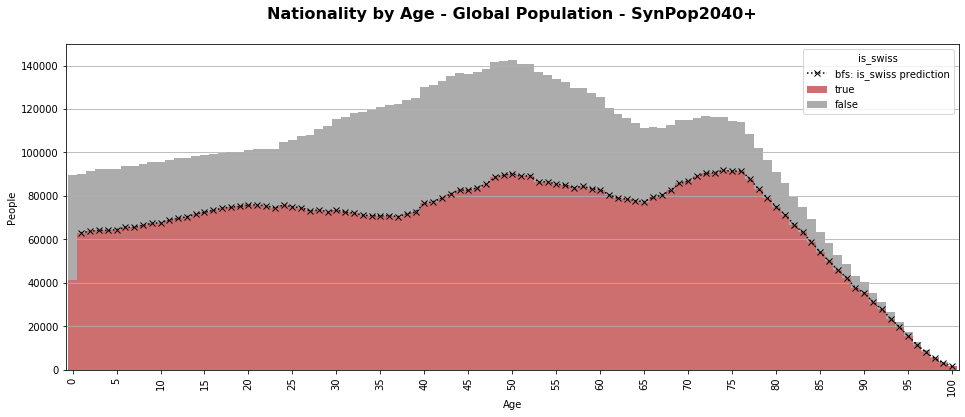

In [37]:
title = 'Nationality by Age - Global Population - SynPop{}+'.format(YEAR)

ax = plot_binary_feature_per_age_with_marginals(counts_per_cat_fixed.groupby(level=1).sum(), 
                                                expected_true_counts_fixed.groupby(level=1).sum(),
                                                colour_dict=COLOUR_DICT, ymax=150_000, title=title)

save_figure(SAVE_OUTPUTS, '02_01_SynPop{}plus_nationality_global.{}'.format(YEAR, FIG_FORMAT),
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

#### A few examples

*Ticino*

In [38]:
CANTON = 'Ticino'

In [39]:
marginals_fixed.loc[CANTON]

expected_ratios_2040  counts_2040  expected_counts_2040  \
age is_swiss                                                            
0   False                 0.000000         1887                     0   
    True                  0.000000         1826                     0   
1   False                 0.277286          987                   986   
    True                  0.722714         2570                  2570   
2   False                 0.283211          975                   974   
...                            ...          ...                   ...   
129 True                  0.000000            1                     0   
131 False                 0.000000            0                     0   
    True                  0.000000            0                     0   
132 False                 0.000000            0                     0   
    True                  0.000000            0                     0   

              deltas_2040  
age is_swiss               
0   False            1887  
    True             1826  
1   False               1  
    True                0  
2   False               1  
...                   ...  
129 True                1  
131 False               0  
    True                0  
132 False               0  
    True                0  

[264 rows x 4 columns]

2020-04-20 15:57:24,740 - INFO - root: Figure saved to file : ./outputs\02_02_SynPop2040plus_nationality_ticino.png


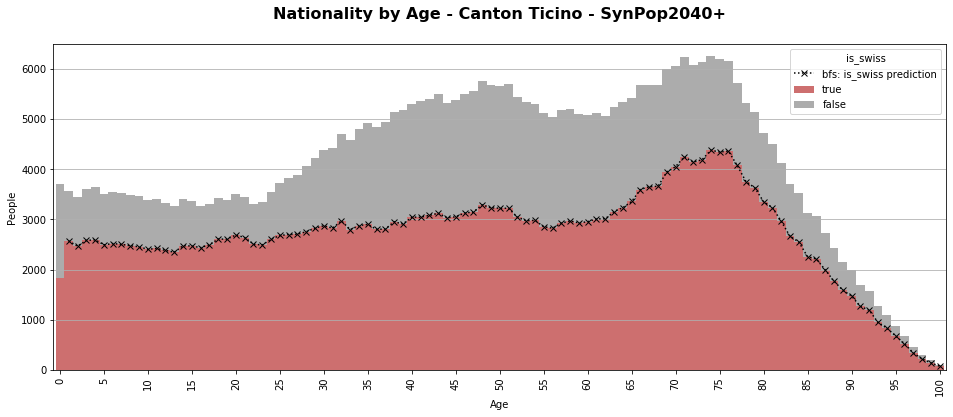

In [40]:
title = 'Nationality by Age - Canton {} - SynPop{}+'.format(CANTON, YEAR)

ax = plot_binary_feature_per_age_with_marginals(counts_per_cat_fixed.loc[CANTON], 
                                                expected_true_counts_fixed.loc[CANTON],
                                                colour_dict=COLOUR_DICT, ymax=6_500, title=title)

save_figure(SAVE_OUTPUTS, '02_02_SynPop{}plus_nationality_ticino.{}'.format(YEAR, FIG_FORMAT),
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

*Zürich*

In [41]:
CANTON = 'Zürich'

In [42]:
marginals_fixed.loc[CANTON]

expected_ratios_2040  counts_2040  expected_counts_2040  \
age is_swiss                                                            
0   False                 0.000000         8668                     0   
    True                  0.000000         6463                     0   
1   False                 0.315614         4896                  4895   
    True                  0.684386        10616                 10616   
2   False                 0.317909         5069                  5068   
...                            ...          ...                   ...   
129 True                  0.000000            0                     0   
131 False                 0.000000            0                     0   
    True                  0.000000            0                     0   
132 False                 0.000000            0                     0   
    True                  0.000000            2                     0   

              deltas_2040  
age is_swiss               
0   False            8668  
    True             6463  
1   False               1  
    True                0  
2   False               1  
...                   ...  
129 True                0  
131 False               0  
    True                0  
132 False               0  
    True                2  

[264 rows x 4 columns]

2020-04-20 15:57:26,616 - INFO - root: Figure saved to file : ./outputs\02_03_SynPop2040plus_nationality_zurich.png


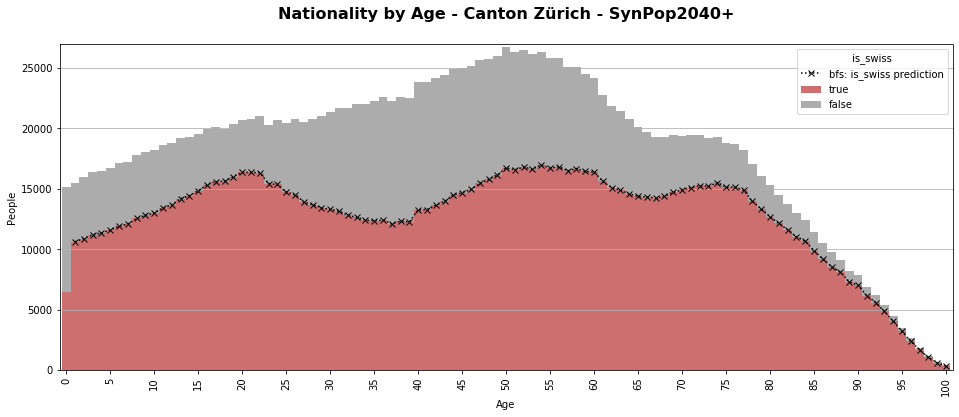

In [43]:
title = 'Nationality by Age - Canton {} - SynPop{}+'.format(CANTON, YEAR)

ax = plot_binary_feature_per_age_with_marginals(counts_per_cat_fixed.loc[CANTON], 
                                                expected_true_counts_fixed.loc[CANTON],
                                                colour_dict=COLOUR_DICT, ymax=27_000, title=title)

save_figure(SAVE_OUTPUTS, '02_03_SynPop{}plus_nationality_zurich.{}'.format(YEAR, FIG_FORMAT),
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

## Saving Results

In [44]:
OUTPUT_DIR

'./outputs'

In [45]:
%%time
if SAVE_OUTPUTS:
    results_file = os.path.join(OUTPUT_DIR, 'fixed_is_swiss.pickle.gzip')
    fixed_swiss.to_pickle(results_file, compression='gzip')

Wall time: 3min 46s


## Export Notebook to HTML

In [47]:
### Write notebook to a html file
!jupyter nbconvert --to html 02_Marginal_Fitting_Nationality.ipynb

[NbConvertApp] Converting notebook 02_Marginal_Fitting_Nationality.ipynb to html
[NbConvertApp] Writing 665155 bytes to 02_Marginal_Fitting_Nationality.html
